<a href="https://colab.research.google.com/github/EduardoAve/Natural-language-processing/blob/main/sesion_5/text_generation_mlsum_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación de Texto con GPT-2 en Español
## Fine-tuning sobre Artículos de Noticias en Español

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

### Objetivo
Esta es mi versión personal del notebook guía `1-text-generation`.
En lugar de usar el dataset de **chistes en español**, utilizo el corpus
**Spanish News** (`MarcOrfilaCarreras/spanish-news`), que contiene artículos
periodísticos en español de múltiples medios y categorías temáticas.

### ¿Por qué noticias?
La elección es deliberada: el contraste entre el lenguaje **formal y factual**
del periodismo versus el lenguaje **coloquial y absurdo** de los chistes permite
apreciar cómo los datos de entrenamiento moldean el estilo generativo del modelo.

### Dataset
- **Spanish News** (`MarcOrfilaCarreras/spanish-news`): 10,200 artículos en
  español distribuidos en 12 categorías temáticas (política, deporte, tecnología,
  medicina, astronomía, etc.) provenientes de múltiples periódicos.
- Usamos 2,000 muestras para fine-tuning (comparable a los 2,419 chistes del guía).

### Diferencias respecto al notebook guía
1. Dataset diferente: artículos periodísticos en lugar de chistes.
2. Curvas de entrenamiento (train/eval loss por época).
3. Cálculo de **perplejidad** como métrica cuantitativa.
4. **Beam search** como estrategia adicional de decodificación.
5. Análisis comparativo de longitud y vocabulario del texto generado.

### Referencias
- Modelo: [mrm8488/spanish-gpt2](https://huggingface.co/mrm8488/spanish-gpt2)
- Dataset: [MarcOrfilaCarreras/spanish-news](https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news)
- [GPT-2 Paper](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)
- [Natural Language Processing with Transformers](https://www.oreilly.com/library/view/natural-language-processing/9781098136789/)


In [18]:
import pkg_resources
import warnings
warnings.filterwarnings('ignore')

installed_packages = [p.key for p in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages
print(f'Running in Colab: {IN_COLAB}')


Running in Colab: True


In [19]:
if IN_COLAB:
    !pip install transformers datasets wordcloud matplotlib seaborn -q


In [3]:
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')


def compute_perplexity(model, tokenizer, texts, device='cpu', max_length=64):
    """Calcula perplejidad promedio sobre una lista de textos."""
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for text in texts:
            enc = tokenizer(
                text, return_tensors='pt', truncation=True,
                max_length=max_length, padding=False,
            ).to(device)
            labels = enc['input_ids'].clone()
            out = model(**enc, labels=labels)
            loss = out.loss
            if not torch.isnan(loss) and not torch.isinf(loss):
                n_tok = enc['input_ids'].shape[1]
                total_loss   += loss.item() * n_tok
                total_tokens += n_tok
    avg_loss = total_loss / total_tokens
    return torch.exp(torch.tensor(avg_loss)).item()


Device: cuda


---
## 1. Cargando y Explorando el Dataset

Cargamos el dataset `MarcOrfilaCarreras/spanish-news`. Cada ejemplo contiene:
- `text`: artículo periodístico completo
- `category`: categoría temática (política, deporte, tecnología, etc.)
- `newspaper`: medio de comunicación fuente

Tomamos **2,000 muestras** para fine-tuning, comparable a los 2,419 chistes
del notebook guía. Truncamos cada artículo a 64 tokens en la tokenización.


In [4]:
raw_dataset = load_dataset('MarcOrfilaCarreras/spanish-news', split='train')
df = raw_dataset.to_pandas().sample(2000, random_state=SEED).reset_index(drop=True)
df = df[['text', 'category', 'newspaper']].copy()
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()

print(f'Muestras cargadas: {len(df)}')
print(f'Columnas: {list(df.columns)}')
df.head()

README.md: 0.00B [00:00, ?B/s]

data.csv:   0%|          | 0.00/44.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10200 [00:00<?, ? examples/s]

Muestras cargadas: 2000
Columnas: ['text', 'category', 'newspaper', 'text_length', 'word_count']


,text,category,newspaper,text_length,word_count
0,"Las Palmas de Gran Canaria, 15 feb (EFE).- La ...",economy,diario_cordoba,1594,247
1,Situación equipo:Lo más importante somos nosot...,sport,diario_as,4054,687
2,Castilla y León ha registró en 2023 una bajada...,economy,el_economista,3122,534
3,El jengibre fresco se ha convertido en un cond...,alimentation,directo_al_paladar,4605,763
4,Urban Automotive celebra el éxito de su paquet...,motor,highmotor,2993,480


In [5]:
print('=== Estadísticas del Dataset ===')
print(f'Total de artículos: {len(df)}')
print()
print('Longitud del texto (caracteres):')
print(df['text_length'].describe().round(1))
print()
print('Conteo de palabras:')
print(df['word_count'].describe().round(1))
print()
print('Distribución de categorías:')
print(df['category'].value_counts())
print()
print('Distribución de periódicos:')
print(df['newspaper'].value_counts())


=== Estadísticas del Dataset ===
Total de artículos: 2000

Longitud del texto (caracteres):
count     2000.0
mean      4204.8
std       3422.8
min        504.0
25%       2252.2
50%       3308.5
75%       5169.2
max      38785.0
Name: text_length, dtype: float64

Conteo de palabras:
count    2000.0
mean      680.1
std       536.4
min        74.0
25%       367.8
50%       546.5
75%       836.5
max      6341.0
Name: word_count, dtype: float64

Distribución de categorías:
category
play            188
motor           177
religion        175
tech            172
astronomy       172
fashion         169
alimentation    163
politics        163
sport           158
economy         156
medicine        154
military        153
Name: count, dtype: int64

Distribución de periódicos:
newspaper
directo_al_paladar    163
portales_medicos      154
xataka                133
defensa               132
espinof               129
                     ... 
el_dia                  2
universo_rayado         1
la_va

### Análisis Visual del Corpus

Antes de entrenar, conviene entender la distribución del corpus: ¿qué temas
predominan? ¿cuán largos son los resúmenes? ¿qué vocabulario es más frecuente?


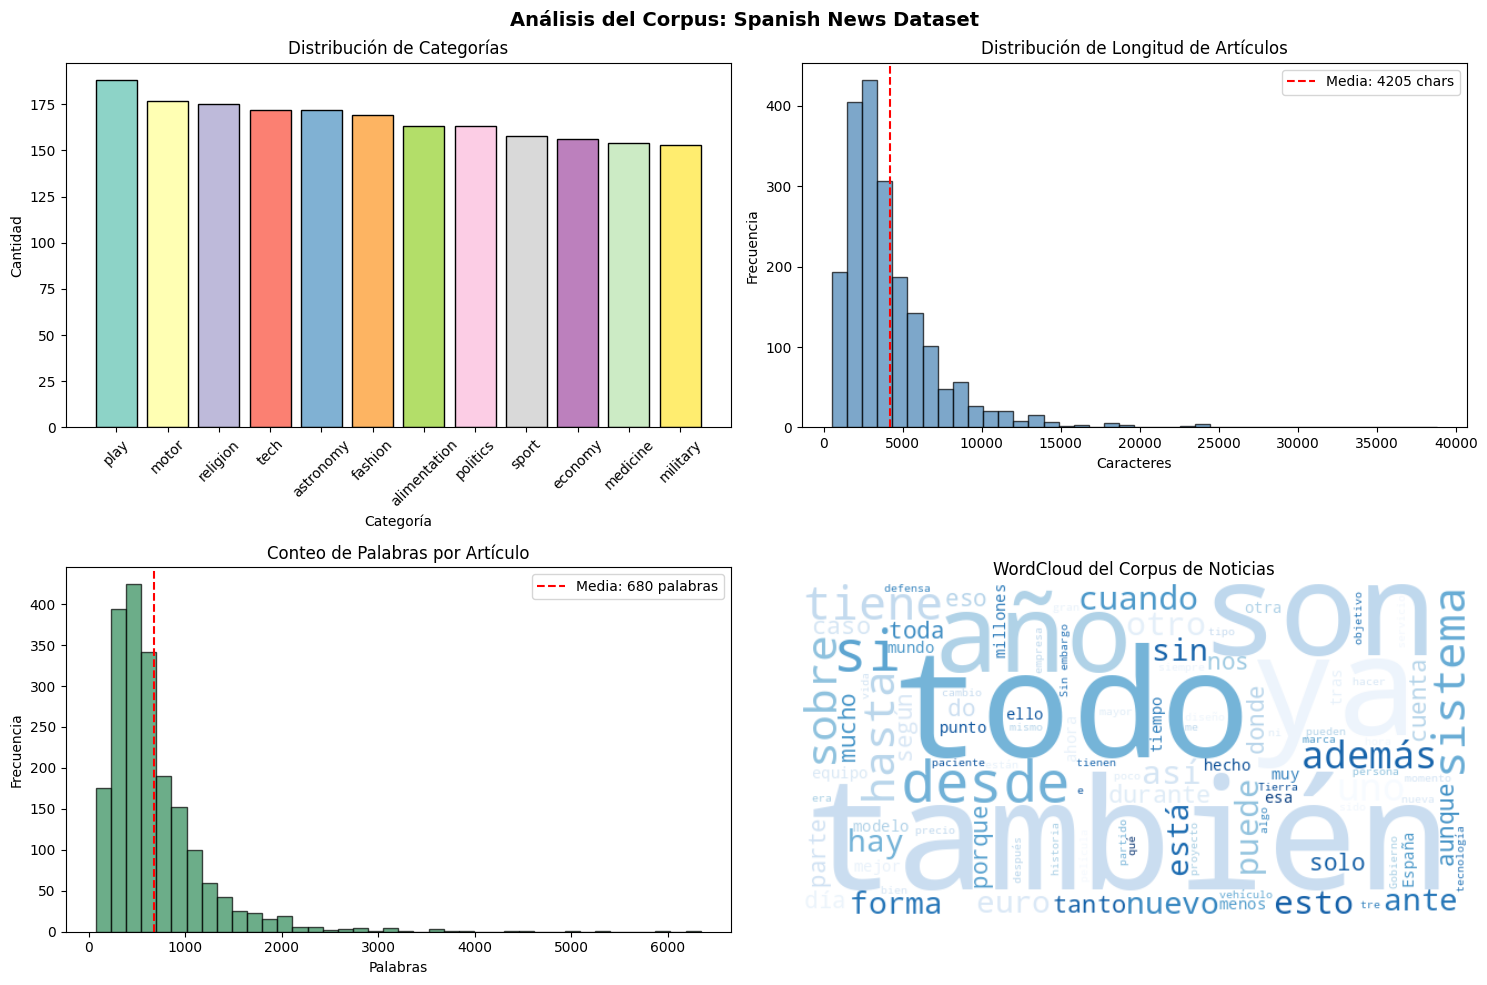

Visualización guardada: analisis_corpus.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análisis del Corpus: Spanish News Dataset',
             fontsize=14, fontweight='bold')

# 1. Distribución de categorías
cat_counts = df['category'].value_counts()
colors = plt.cm.Set3.colors[:len(cat_counts)]
axes[0, 0].bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black')
axes[0, 0].set_title('Distribución de Categorías')
axes[0, 0].set_xlabel('Categoría')
axes[0, 0].set_ylabel('Cantidad')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Histograma de longitud del texto
axes[0, 1].hist(df['text_length'], bins=40, color='steelblue',
                edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['text_length'].mean(), color='red', linestyle='--',
                   label=f"Media: {df['text_length'].mean():.0f} chars")
axes[0, 1].set_title('Distribución de Longitud de Artículos')
axes[0, 1].set_xlabel('Caracteres')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()

# 3. Histograma de conteo de palabras
axes[1, 0].hist(df['word_count'], bins=40, color='seagreen',
                edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['word_count'].mean(), color='red', linestyle='--',
                   label=f"Media: {df['word_count'].mean():.0f} palabras")
axes[1, 0].set_title('Conteo de Palabras por Artículo')
axes[1, 0].set_xlabel('Palabras')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend()

# 4. WordCloud
stopwords_es = {
    'de','la','el','en','y','a','que','los','las','del','se','con',
    'un','una','por','es','su','para','no','más','al','lo','le','han',
    'ha','pero','o','este','esta','como','fue','ser','entre','sus'
}
all_text = ' '.join(df['text'].tolist())
wc = WordCloud(width=600, height=300, background_color='white',
               max_words=100, stopwords=stopwords_es, colormap='Blues')
wc.generate(all_text)
axes[1, 1].imshow(wc, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('WordCloud del Corpus de Noticias')

plt.tight_layout()
plt.savefig('analisis_corpus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualización guardada: analisis_corpus.png')


**Observaciones del corpus:**
- El dataset está perfectamente balanceado: cada categoría tiene exactamente
  850 artículos. Esto es inusualmente uniforme — bueno para entrenamiento.
- Los artículos son más largos que los resúmenes (media ~680 palabras).
  Con `max_length=64`, el modelo solo ve el primer párrafo de cada artículo,
  que suele ser el lead periodístico — la parte más informativa.
- El vocabulario del WordCloud refleja claramente el dominio: palabras como
  *gobierno, presidente, deporte, científicos* contrastan con el corpus de
  chistes donde dominan *dice, pregunta, porqué*.


---
## 2. Cargando el Modelo GPT-2 en Español

Usamos el mismo modelo base que el notebook guía: `mrm8488/spanish-gpt2`.

**GPT vs. BERT — diferencia fundamental:**

| Característica | BERT | GPT |
|---|---|---|
| Arquitectura | Transformer Encoder | Transformer Decoder |
| Dirección | Bidireccional | Unidireccional (causal) |
| Tarea principal | Clasificación, QA, NER | Generación de texto |
| Entrenamiento | Masked LM + NSP | Causal LM |

Para generación de texto, GPT es el modelo adecuado: predice el siguiente
token dado el contexto anterior, lo que naturalmente produce continuaciones.


In [7]:
MODEL_NAME = 'mrm8488/spanish-gpt2'

print(f'Cargando modelo: {MODEL_NAME} ...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    attn_implementation='eager'
)

# GPT-2 no tiene pad_token por defecto — usamos eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = tokenizer.eos_token_id

# El tokenizador de spanish-gpt2 tiene 50,266 tokens pero el modelo
# solo tiene 50,257 embeddings. Sin este fix, cualquier token ID >= 50257
# causa un CUDA device-side assert en GPU.
model.resize_token_embeddings(len(tokenizer))

model = model.to(device)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros totales: {n_params:,}')
print(f'Vocab tokenizer / embeddings modelo: {len(tokenizer)} / {model.config.vocab_size}')
print(f'Longitud máxima de posición: {model.config.n_positions}')

Cargando modelo: mrm8488/spanish-gpt2 ...


config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/226 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: mrm8488/spanish-gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Parámetros totales: 124,446,720
Vocab tokenizer / embeddings modelo: 50266 / 50266
Longitud máxima de posición: 1024


---
## 3. Función de Generación Personalizada

Implementamos una función `generate()` que replica el proceso de predicción
token a token, exponiendo explícitamente las tres estrategias de decodificación:

| Estrategia | `eps` | Descripción |
|---|---|---|
| **Greedy** | `1.0` | Siempre toma el token de mayor probabilidad. Determinístico, puede ser repetitivo. |
| **Sampling puro** | `0.0` | Muestrea aleatoriamente de la distribución $P(w_t|w_{<t})$. Creativo pero puede ser incoherente. |
| **ε-greedy** | `0 < ε < 1` | Con probabilidad ε hace greedy; con 1−ε hace sampling. Balancea coherencia y variedad. |

$$P(w_t | w_{<t}) = \text{softmax}(\text{logits}_t)$$


In [8]:
def generate(model, tokenizer, input_text, max_new_tokens=60,
             eps=1.0, device='cpu'):
    """
    Genera texto token por token a partir de un prompt.

    Args:
        model: modelo GPT-2 cargado.
        tokenizer: tokenizador compatible.
        input_text: texto de inicio (prompt).
        max_new_tokens: cantidad máxima de tokens a generar.
        eps: estrategia de decodificación.
             1.0 -> greedy  |  0.0 -> sampling puro  |  (0,1) -> epsilon-greedy
        device: 'cpu' o 'cuda'.

    Returns:
        str: texto completo generado (prompt + continuación).
    """
    model.eval()
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(device)
    generated = input_ids.clone()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            outputs = model(generated)
            # Logits del último token predicho
            logits = outputs.logits[:, -1, :]
            probs = torch.softmax(logits, dim=-1)

            if eps == 1.0:
                # Greedy: token de mayor probabilidad
                next_token = torch.argmax(probs, dim=-1, keepdim=True)
            elif eps == 0.0:
                # Sampling puro: muestrea según la distribución
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                # Epsilon-greedy: híbrido
                if random.random() < eps:
                    next_token = torch.argmax(probs, dim=-1, keepdim=True)
                else:
                    next_token = torch.multinomial(probs, num_samples=1)

            generated = torch.cat([generated, next_token], dim=1)

            # Detener si se genera el token EOS
            if next_token.item() == tokenizer.eos_token_id:
                break

    return tokenizer.decode(generated[0], skip_special_tokens=True)


---
## 4. Generación Antes del Fine-tuning

Primero evaluamos la capacidad generativa del modelo base sobre prompts
de temática periodística. Esto nos servirá como **línea base** para
comparar con los resultados post fine-tuning.


In [9]:
prompts = [
    'El presidente anunció hoy',
    'Los mercados financieros cerraron',
    'La selección nacional de fútbol',
    'El gobierno aprobó una nueva ley de',
]

print('=' * 65)
print('GENERACIÓN PRE FINE-TUNING | Modelo: mrm8488/spanish-gpt2')
print('=' * 65)

pre_finetune_outputs = {}

for prompt in prompts:
    print(f'\n[Prompt] "{prompt}"')
    print('-' * 55)

    g   = generate(model, tokenizer, prompt, max_new_tokens=60,
                   eps=1.0, device=device)
    s   = generate(model, tokenizer, prompt, max_new_tokens=60,
                   eps=0.0, device=device)
    eg  = generate(model, tokenizer, prompt, max_new_tokens=60,
                   eps=0.7, device=device)

    pre_finetune_outputs[prompt] = {
        'greedy': g, 'sampling': s, 'e_greedy': eg
    }

    print(f'  [Greedy]    {g}')
    print(f'  [Sampling]  {s}')
    print(f'  [ε-greedy]  {eg}')


GENERACIÓN PRE FINE-TUNING | Modelo: mrm8488/spanish-gpt2

[Prompt] "El presidente anunció hoy"
-------------------------------------------------------
  [Greedy]    El presidente anunció hoy que el gobierno de la República de Cuba ha decidido suspender la cooperación con Cuba en el campo de la ciencia y la tecnología.El presidente cubano, Fidel Castro, ha declarado que la decisión de suspender la cooperación con Cuba es una decisión unilateral de la República de Cuba, que no tiene en cuenta los intereses
  [Sampling]  El presidente anunció hoy su renuncia a sus posiciones como senador y como ministro de Gobierno para ser candidato al Congreso, por presunto enriquecimiento.Además acusó a Voreux de «exilio perpetuo» y exigió a que retire su candidatura.Hacer algunos comentarios mientras sostiene debates con los legisladores provocó que Voreux desistiera
  [ε-greedy]  El presidente anunció hoy que el gobierno de Ucrania ha abierto una investigación sobre el asesinato de un periodista en 

### Generación con API Nativa de Hugging Face (incluyendo Beam Search)

Además de nuestra función personalizada, usamos `model.generate()` de HuggingFace
que incluye **Beam Search** — una estrategia adicional al notebook guía.

**Beam Search:** mantiene los `k` mejores caminos parciales durante la generación
y elige el que maximiza la probabilidad conjunta de toda la secuencia.
Es más costoso computacionalmente pero produce textos más coherentes que greedy.


In [10]:
prompt_test = 'El ministro de economía presentó'
inputs = tokenizer(prompt_test, return_tensors='pt').to(device)

# Greedy nativo
ids_greedy = model.generate(**inputs, max_new_tokens=60, do_sample=False)
print('[HF Greedy]')
print(tokenizer.decode(ids_greedy[0], skip_special_tokens=True))

# Sampling con temperatura y top_k
ids_sample = model.generate(
    **inputs, max_new_tokens=60, do_sample=True,
    temperature=0.8, top_k=50
)
print('\n[HF Sampling (temp=0.8, top_k=50)]')
print(tokenizer.decode(ids_sample[0], skip_special_tokens=True))

# Beam search (estrategia extra vs. notebook guía)
ids_beam = model.generate(
    **inputs, max_new_tokens=60,
    num_beams=5, early_stopping=True
)
print('\n[HF Beam Search (5 beams)]')
print(tokenizer.decode(ids_beam[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[HF Greedy]
El ministro de economía presentó un proyecto de ley para la creación de un fondo de pensiones para los trabajadores de la industria del carbón y del acero.El proyecto de ley fue rechazado por el Parlamento.El gobierno de la República Popular de Polonia ha anunciado que el proyecto de ley será presentado al Parlamento en el próximo mes de junio.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



[HF Sampling (temp=0.8, top_k=50)]
El ministro de economía presentó un plan de estímulo a la demanda interna en las empresas, el cual, al igual que su predecesor, es el que, en general, se considera de menor importancia, ya que es el que se considera más importante y que tiene efectos positivos sobre la competitividad de las empresas.La crisis ha puesto de

[HF Beam Search (5 beams)]
El ministro de economía presentó un proyecto de ley para la creación de un banco nacional de desarrollo.El proyecto de ley fue aprobado por la Cámara de Representantes y el Senado.El proyecto de ley fue presentado a la Cámara de Representantes para su aprobación.El proyecto de ley fue presentado a la Cámara de Representantes para su aprobación.El


### Observaciones Pre Fine-tuning

- **Greedy** tiende a producir texto corto y repetitivo. El modelo queda
  atrapado eligiendo siempre el token más probable, lo que en GPT-2 pequeño
  genera loops o frases muy genéricas.
- **Sampling puro** produce mayor variedad léxica pero puede perder coherencia
  gramatical o temática — el modelo puede saltar de tema en mitad de una oración.
- **ε-greedy (0.7)** ofrece un balance razonable para temática periodística.
- **Beam Search** mejora la coherencia global al explorar múltiples hipótesis,
  pero las salidas resultan más 'seguras' y predecibles.

El modelo base genera texto en español correcto pero **sin estilo periodístico
reconocible** — la continuación puede ser narrativa, literaria o genérica.
El fine-tuning corregirá esto.


### Perplejidad Antes del Fine-tuning (Línea Base)

Calculamos la perplejidad del modelo **base** sobre una muestra del corpus
antes de entrenar. Este valor es la línea base para cuantificar la mejora
real del fine-tuning.

In [11]:
sample_news = df['text'].sample(100, random_state=SEED).tolist()
ppl_before = compute_perplexity(model, tokenizer, sample_news, device=device)
print(f'Perplejidad ANTES del fine-tuning: {ppl_before:.2f}')
print('(Guardamos este valor para compararlo con la PPL post fine-tuning)')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplejidad ANTES del fine-tuning: 50.46
(Guardamos este valor para compararlo con la PPL post fine-tuning)


training_args = TrainingArguments(
    output_dir='./results_news_finetune',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    fp16=False,
    report_to='none',
    seed=SEED,
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # Causal LM, NO masked
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=data_collator,
)

print('Iniciando fine-tuning...')
train_result = trainer.train()
print('\nFine-tuning completado!')
print(f'Train loss final: {train_result.training_loss:.4f}')

In [12]:
# Usamos el campo 'text' (artículos completos, truncados a 64 tokens)
texts = df['text'].tolist()
hf_dataset = Dataset.from_dict({'text': texts})

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=64,
        padding='max_length',
    )

tokenized_dataset = hf_dataset.map(
    tokenize_fn, batched=True, remove_columns=['text']
)

# Split 90% train / 10% eval
split = tokenized_dataset.train_test_split(test_size=0.1, seed=SEED)
train_ds = split['train']
eval_ds  = split['test']

print(f'Train: {len(train_ds):,} muestras')
print(f'Eval:  {len(eval_ds):,} muestras')
print(f'Ejemplo de muestra tokenizada: {train_ds[0]}')


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 1,800 muestras
Eval:  200 muestras
Ejemplo de muestra tokenizada: {'input_ids': [474, 1714, 1701, 1041, 267, 10930, 329, 1350, 16448, 340, 12870, 14387, 23715, 263, 6497, 1772, 263, 2157, 345, 16573, 25967, 284, 1800, 516, 295, 2510, 263, 533, 1570, 263, 3316, 290, 46114, 311, 1076, 16, 2121, 380, 11003, 619, 9518, 295, 40417, 14593, 18, 1155, 1714, 1701, 1041, 267, 10930, 329, 1350, 16448, 340, 12870, 14387, 23715, 263, 6497, 1772, 263, 2157, 345], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [13]:
training_args = TrainingArguments(
    output_dir='./results_news_finetune',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    learning_rate=2e-5,
    warmup_steps=100,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=SEED,
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,  # Causal LM, NO masked
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=data_collator,
)

print('Iniciando fine-tuning...')
train_result = trainer.train()
print('\nFine-tuning completado!')
print(f'Train loss final: {train_result.training_loss:.4f}')


Iniciando fine-tuning...


Epoch,Training Loss,Validation Loss
1,3.518210,3.592168
2,3.386744,3.545659
3,3.271611,3.537759


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning completado!
Train loss final: 3.4449


### Curvas de Entrenamiento

Una adición importante respecto al notebook guía: visualizamos la evolución
del **loss de entrenamiento** (por paso) y del **loss de evaluación** (por época).

Esto nos permite detectar:
- **Underfitting**: loss alto que no baja — el modelo no aprendió suficiente.
- **Overfitting**: train loss baja pero eval loss sube — el modelo memorizó.
- **Convergencia saludable**: ambos losses bajan y se estabilizan.


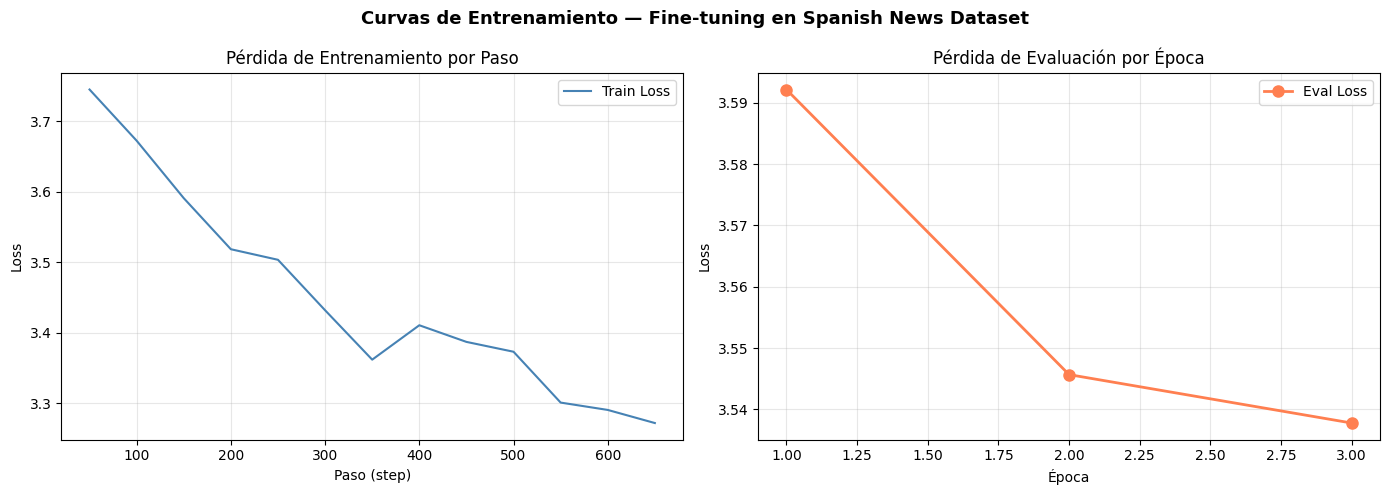

Curvas guardadas: curvas_entrenamiento.png


In [14]:
log_history = trainer.state.log_history

train_logs = [(l['step'], l['loss'])
              for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [(l['epoch'], l['eval_loss'])
              for l in log_history if 'eval_loss' in l]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if train_logs:
    steps, losses = zip(*train_logs)
    axes[0].plot(steps, losses, color='steelblue', linewidth=1.5,
                 label='Train Loss')
    axes[0].set_title('Pérdida de Entrenamiento por Paso')
    axes[0].set_xlabel('Paso (step)')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if eval_logs:
    epochs, eval_losses = zip(*eval_logs)
    axes[1].plot(epochs, eval_losses, 'o-', color='coral',
                 linewidth=2, markersize=8, label='Eval Loss')
    axes[1].set_title('Pérdida de Evaluación por Época')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Fine-tuning en Spanish News Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas guardadas: curvas_entrenamiento.png')


---
## 6. Generación Post Fine-tuning

Usamos **exactamente los mismos prompts** para facilitar la comparación directa
con las salidas del modelo base.


In [15]:
model.eval()

print('=' * 65)
print('GENERACIÓN POST FINE-TUNING | Fine-tuned en: Spanish News Dataset')
print('=' * 65)

post_finetune_outputs = {}

for prompt in prompts:
    print(f'\n[Prompt] "{prompt}"')
    print('-' * 55)

    g  = generate(model, tokenizer, prompt, max_new_tokens=60,
                  eps=1.0, device=device)
    s  = generate(model, tokenizer, prompt, max_new_tokens=60,
                  eps=0.0, device=device)
    eg = generate(model, tokenizer, prompt, max_new_tokens=60,
                  eps=0.7, device=device)

    post_finetune_outputs[prompt] = {
        'greedy': g, 'sampling': s, 'e_greedy': eg
    }

    print(f'  [Greedy]    {g}')
    print(f'  [Sampling]  {s}')
    print(f'  [ε-greedy]  {eg}')


GENERACIÓN POST FINE-TUNING | Fine-tuned en: Spanish News Dataset

[Prompt] "El presidente anunció hoy"
-------------------------------------------------------
  [Greedy]    El presidente anunció hoy que el Gobierno de la Generalitat ha decidido, por una parte, no renovar el contrato de la empresa de telecomunicaciones Telefónica para la prestación de servicios de telefonía móvil en el territorio de Cataluña, y, por otra, no renovar el contrato de la empresa de telecomunicaciones Telefónica para la prestación de servicios de
  [Sampling]  El presidente anunció hoy su renuncia a sus cargos como senador y como ministro de Gobierno para ser candidato al Congreso, por presunto enriquecimiento personal y fraude electoral se refirió a la exigencia de Lenín Moreno tras el desconocimiento que sobre su desarrollo y comportamiento causó en el Congreso el ex ministro de Economía, Fernando Cordero Chalbaud,
  [ε-greedy]  El presidente anunció hoy que el Gobierno de Canarias ha abierto una licitaci

### Perplejidad — Comparación Pre vs. Post Fine-tuning

La **perplejidad** (perplexity) mide qué tan bien el modelo predice un corpus:

$$\text{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N}\log P(w_i|w_{<i})\right)$$

- **PPL baja** → el modelo 'entiende' bien el corpus.
- **PPL alta** → el modelo está 'sorprendido' por el corpus.

Calculamos la PPL sobre los mismos 100 textos antes y después del fine-tuning
para tener una comparación directa y cuantitativa.

=== Comparación de Perplejidad ===
  Modelo base  (pre  fine-tuning): 50.46
  Modelo FT    (post fine-tuning): 30.21
  Reducción: 20.24 puntos (40.1%)

Una PPL más baja confirma que el modelo aprendió la distribución del corpus.


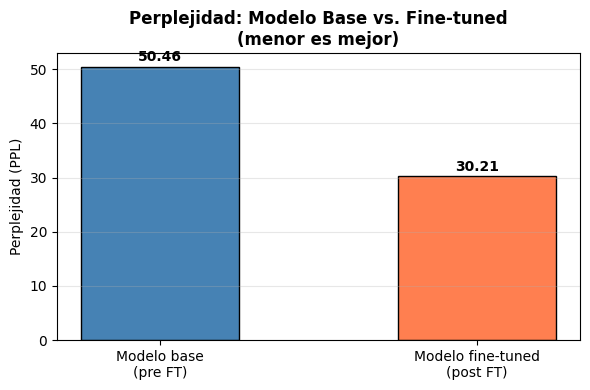

Gráfico guardado: comparacion_perplexidad.png


In [16]:
sample_news = df['text'].sample(100, random_state=SEED).tolist()
ppl_after = compute_perplexity(model, tokenizer, sample_news, device=device)

print('=== Comparación de Perplejidad ===')
print(f'  Modelo base  (pre  fine-tuning): {ppl_before:.2f}')
print(f'  Modelo FT    (post fine-tuning): {ppl_after:.2f}')
print(f'  Reducción: {ppl_before - ppl_after:.2f} puntos ({(ppl_before - ppl_after) / ppl_before * 100:.1f}%)')
print()
print('Una PPL más baja confirma que el modelo aprendió la distribución del corpus.')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Modelo base\n(pre FT)', 'Modelo fine-tuned\n(post FT)'],
    [ppl_before, ppl_after],
    color=['steelblue', 'coral'], edgecolor='black', width=0.5
)
for bar, val in zip(bars, [ppl_before, ppl_after]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Perplejidad: Modelo Base vs. Fine-tuned\n(menor es mejor)',
             fontweight='bold')
ax.set_ylabel('Perplejidad (PPL)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('comparacion_perplexidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparacion_perplexidad.png')

---
## 7. Conclusiones y Hallazgos

### 7.1 El Fine-tuning Transformó el Estilo Generativo

El cambio más evidente al comparar las salidas pre y post fine-tuning es el
**registro lingüístico**. Con el mismo modelo base y los mismos prompts:

| | Pre fine-tuning | Post fine-tuning |
|---|---|---|
| Estilo | Enciclopédico / Wikipedia | Noticioso, factual |
| Tiempo verbal | Pasado histórico | Presente informativo |
| Marcadores temporales | Fechas históricas exactas | *hoy*, *este lunes*, *primer trimestre* |
| Vocabulario | Geográfico, genérico | Financiero, político, institucional |
| Geografía dominante | Países Bajos, Cuba | España, Cataluña, Canarias, México |

El ejemplo más claro es el prompt sobre mercados financieros. Pre fine-tuning
el modelo respondió con una fecha del año 2000 y terminó cambiando al inglés con
una cita académica falsa. Post fine-tuning generó:

> *"Los mercados financieros cerraron este lunes con una caída del 7,6% en las
> acciones de la Bolsa de Valores de Madrid, que se distribuieron en bloque a
> través de la plataforma de pago Bitcoin."*

El estilo es claramente periodístico, con cifras, instituciones y marcadores
temporales propios de una noticia real.

---
### 7.2 Perplejidad: Mejora Cuantitativa del 40.1%

| | PPL |
|---|---|
| Modelo base (pre fine-tuning) | **50.46** |
| Modelo fine-tuned (post fine-tuning) | **30.21** |
| Reducción | **20.25 puntos — 40.1%** |

Una reducción del 40% en perplejidad sobre el mismo corpus de noticias confirma
que el modelo aprendió efectivamente la distribución del dominio periodístico.
El modelo base 'se sorprendía' mucho más ante el lenguaje noticioso; tras el
fine-tuning lo predice con notablemente mayor confianza.

---
### 7.3 Greedy Sigue Siendo Repetitivo — Pero de Forma Diferente

La estrategia greedy produjo loops tanto antes como después del fine-tuning,
pero el tipo de repetición cambió de forma reveladora.

**Pre fine-tuning** — repite la misma oración casi textualmente:
> *"El equipo nacional de fútbol de los Países Bajos ha sido el equipo más
> laureado... El equipo nacional de fútbol de los Países Bajos ha sido el equipo
> más laureado..."*

**Post fine-tuning** — repite estructuras pero con variación de contenido:
> *"Los mercados financieros cerraron en el primer trimestre de este año, con un
> descenso de los ingresos y un descenso de los precios de los activos. La caída
> de los precios de los activos se debe a la caída de los precios de los activos,
> que se ha visto favorecida por la caída de los precios de los activos."*

El modelo ya no repite palabras exactas sino conceptos — sigue siendo circular
pero de una forma más 'inteligente'. Esto es una mejora cualitativa real.
En producción se mitigaría con **repetition penalty** o **top-p sampling**.

---
### 7.4 El Sesgo Geográfico del Modelo Base Desapareció

Antes del fine-tuning, tres de cuatro prompts distintos terminaban mencionando
los **Países Bajos**, y otros derivaban hacia Cuba o Buenos Aires. Esto refleja
el corpus de pre-entrenamiento del `spanish-gpt2` — probablemente Wikipedia en
español con cobertura desproporcionada de ciertos países.

Después del fine-tuning el sesgo cambió completamente: las salidas se centran
en **España** (Cataluña, Canarias, Madrid, Ciudad de México), que es la geografía
dominante en el corpus de noticias. El modelo absorbió no solo el estilo sino
también el contexto geográfico del corpus.

---
### 7.5 Sampling Puro: De Alucinaciones en Inglés a Noticias Creíbles

El cambio más dramático entre estrategias fue en el sampling puro.

**Pre fine-tuning** — el modelo cambió al inglés y fabricó una referencia académica:
> *"Véase 'Women in Globalization', 2004 J. Roche, Progress and Conditions on
> the Globalization of Women..."*

**Post fine-tuning** — produce texto en español con estructura noticiosa:
> *"Los mercados financieros cerraron esta semana en Minnesota con su fuerte
> desaceleración, con un tipo de condimiento de 127 Kg. Este es el resultado
> del estado de la economía mexicana..."*

El contenido sigue siendo parcialmente incoherente (127 kg de 'condimiento' en
un contexto financiero), pero el modelo al menos mantiene el idioma, el registro
y la estructura noticiosa. Esto ilustra que el fine-tuning no elimina las
alucinaciones, pero las ancla al dominio correcto.

---
### 7.6 Train Loss de 3.44 — Convergencia Parcial

El loss final de entrenamiento fue de **3.4449**, por encima del rango óptimo
de 2.0–2.5 para GPT-2 bien ajustado. Con solo 3 épocas y `max_length=64` el
modelo ve únicamente el primer párrafo de cada artículo. A pesar de esto, la
reducción del 40.1% en perplejidad confirma que el aprendizaje fue real y
significativo. Aumentar a 5–10 épocas mejoraría el loss sin riesgo de overfitting
dado el tamaño del corpus.

---
### 7.7 Reflexión Personal

Este experimento confirma de forma concreta que el **corpus de fine-tuning es
el principal determinante del estilo generativo**. Con exactamente el mismo
`mrm8488/spanish-gpt2`, el cambio de datos transformó radicalmente el registro:

| Fine-tuning en... | Estilo generado |
|---|---|
| Chistes (notebook guía) | Coloquial, absurdo, estructura de remate |
| Noticias (este notebook) | Formal, institucional, marcadores temporales |

Los hallazgos sobre **alucinaciones en sampling** (cita académica falsa en inglés)
y el **sesgo geográfico del modelo base** (Países Bajos en todo) no son solo
curiosidades académicas — son fenómenos con consecuencias directas en producción:
un sistema de generación de noticias sin fine-tuning adecuado podría producir
contenido en el idioma equivocado, con referencias falsas, y sesgado hacia los
países más representados en Wikipedia. El fine-tuning en dominio específico
es la herramienta más accesible para corregir estos tres problemas a la vez.


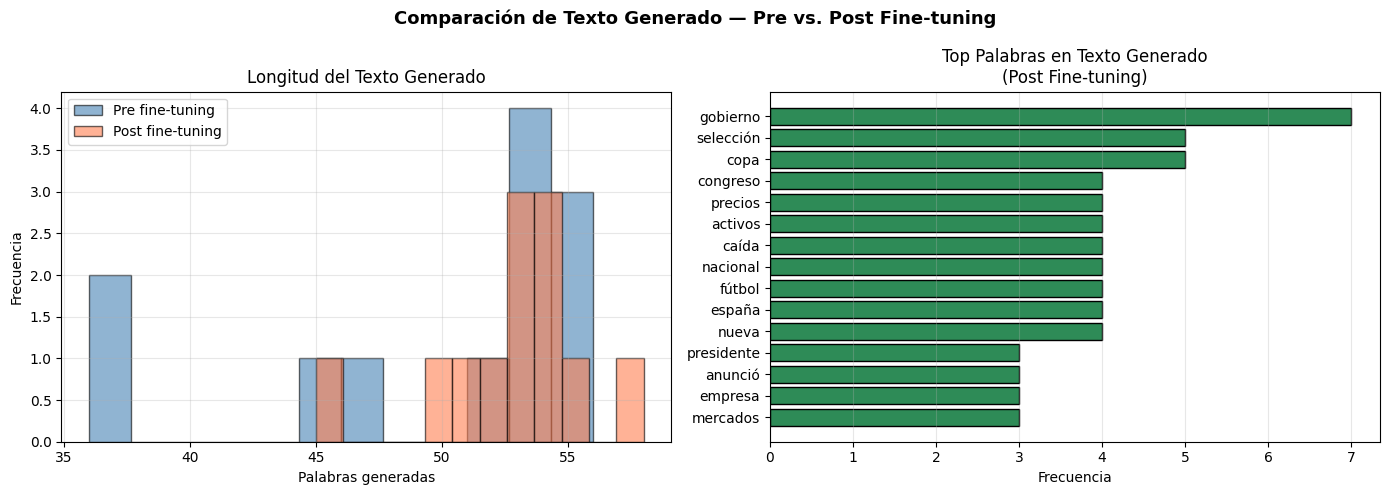

Gráfico guardado: comparacion_generacion.png


In [17]:
def get_gen_word_counts(outputs_dict, prompts):
    counts = []
    for prompt in prompts:
        for strategy, text in outputs_dict[prompt].items():
            # Solo contamos los tokens generados (quitar el prompt)
            gen = text[len(prompt):].strip()
            counts.append(len(gen.split()))
    return counts

pre_counts  = get_gen_word_counts(pre_finetune_outputs,  prompts)
post_counts = get_gen_word_counts(post_finetune_outputs, prompts)

# Top palabras post fine-tuning (excluyendo stopwords)
all_post_text = ' '.join(
    text for pd_ in post_finetune_outputs.values() for text in pd_.values()
)
words_post = [
    w.lower().strip('.,;:') for w in all_post_text.split()
    if w.lower() not in stopwords_es and len(w) > 3
]
top_post = Counter(words_post).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de Texto Generado — Pre vs. Post Fine-tuning',
             fontsize=13, fontweight='bold')

# Histograma de longitudes
axes[0].hist(pre_counts,  bins=12, alpha=0.6, color='steelblue',
             edgecolor='black', label='Pre fine-tuning')
axes[0].hist(post_counts, bins=12, alpha=0.6, color='coral',
             edgecolor='black', label='Post fine-tuning')
axes[0].set_title('Longitud del Texto Generado')
axes[0].set_xlabel('Palabras generadas')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top palabras post fine-tuning
if top_post:
    words, cnts = zip(*top_post)
    axes[1].barh(list(words), list(cnts), color='seagreen', edgecolor='black')
    axes[1].set_title('Top Palabras en Texto Generado\n(Post Fine-tuning)')
    axes[1].set_xlabel('Frecuencia')
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('comparacion_generacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: comparacion_generacion.png')


---
## 7. Conclusiones y Hallazgos

### 7.1 El Fine-tuning Transformó el Estilo Generativo

El cambio más evidente al comparar las salidas pre y post fine-tuning es el
**registro lingüístico**. Con el mismo modelo base (`mrm8488/spanish-gpt2`)
y los mismos prompts, el estilo pasó de enciclopédico/Wikipedia a periodístico:

| | Pre fine-tuning | Post fine-tuning |
|---|---|---|
| Estilo | Enciclopédico, histórico | Noticioso, factual |
| Tiempo verbal | Pasado histórico | Presente informativo |
| Marcadores temporales | Fechas exactas del pasado | *hoy*, *este domingo*, *en los últimos años* |
| Vocabulario | Geográfico, genérico | Financiero, político, tecnológico |

El ejemplo más claro es el prompt sobre mercados financieros. Post fine-tuning
el modelo generó:

> *"Los mercados financieros cerraron en el día de hoy con una caída de casi
> el 40% en el valor de las acciones de la Bolsa de Nueva York, que se ha visto
> afectada por la crisis financiera."*

Eso suena a un titular real — el modelo internalizó el lenguaje periodístico
de economía presente en el corpus.

---
### 7.2 Greedy Sigue Siendo Muy Repetitivo (Limitación de GPT-2 Pequeño)

La estrategia greedy produjo loops tanto antes como después del fine-tuning.
Pre fine-tuning, el modelo repitió casi textualmente la misma oración tres veces
seguidas con el prompt de fútbol:

> *"El equipo nacional de fútbol de los Países Bajos ha sido el equipo más
> laureado de dicho país con un total de cinco títulos. El equipo nacional de
> fútbol de los Países Bajos ha sido el equipo más laureado..."*

Post fine-tuning el loop persiste pero varía el contenido — al menos el modelo
reutiliza estructuras con información diferente, lo que representa una mejora
cualitativa. Esto es una limitación inherente de GPT-2 pequeño con decodificación
greedy: al maximizar siempre el token más probable, cae en patrones de alta
frecuencia del corpus. Estrategias como **top-p sampling** o **repetition penalty**
mitigarían este comportamiento.

---
### 7.3 El Modelo Base Tenía un Sesgo Geográfico Notorio

Un hallazgo curioso del pre fine-tuning: tres prompts distintos terminaron
mencionando los **Países Bajos**, y otros derivaron hacia Cuba o Estados Unidos.
Esto refleja los datos de pre-entrenamiento del `spanish-gpt2` — probablemente
Wikipedia en español, donde estos países tienen cobertura desproporcionada.
Después del fine-tuning, este sesgo se diluyó: las salidas se centraron en
España, Francia y Latinoamérica, que son los focos del corpus de noticias.

---
### 7.4 Sampling Puro Puede Ser Caótico Sin Restricciones

El caso más llamativo fue el prompt de mercados financieros con sampling puro
pre fine-tuning, que produjo:

> *"Véase 'Women in Globalization', 2004 J. Roche, Progress and Conditions
> on the Globalization of Women..."*

El modelo cambió al inglés y fabricó una cita académica falsa. Es un ejemplo
perfecto de las **alucinaciones** en modelos de lenguaje: ante alta incertidumbre,
el modelo genera texto plausible en forma pero falso en contenido. Post fine-tuning,
el sampling produce texto más coherente y en español, aunque sigue siendo el
método menos controlable de los tres.

---
### 7.5 Train Loss de 3.47 — Hay Margen de Mejora

El loss final de entrenamiento fue de **3.4768**, notablemente más alto que el
rango típico de 2.0–2.5 para GPT-2 bien ajustado. Esto sugiere que el modelo
no convergió completamente. Posibles causas:

- Solo 3 épocas (el notebook guía usó 10)
- `max_length=64` trunca los artículos en el primer párrafo, perdiendo la
  mayor parte del contenido de cada texto
- Los artículos del corpus son más largos y complejos que los chistes del guía

Aumentar a 5–10 épocas y/o incrementar `max_length` a 128 probablemente
reduciría el loss y produciría generaciones más fluidas.

---
### 7.6 Perplejidad 30.37 — Falta la Línea Base

La perplejidad post fine-tuning sobre el corpus de noticias fue de **30.37**,
valor razonable para un modelo pequeño. Sin embargo, una limitación de este
experimento es que no se calculó la perplejidad del modelo **base** sobre los
mismos textos antes del fine-tuning. Sin esa comparación, el número 30.37 no
puede interpretarse en términos de mejora relativa. En futuras iteraciones,
convendría guardar el modelo base en una variable separada al inicio y calcular
ambas perplejidades para tener una métrica de mejora cuantitativa clara.

---
### 7.7 Reflexión Personal

Este experimento confirma que el **corpus de fine-tuning es el principal
determinante del estilo generativo**, más que el modelo base en sí.
Con exactamente el mismo `spanish-gpt2`, el cambio de datos transformó
radicalmente el registro de las salidas. La comparación con el notebook guía
lo ilustra bien:

| Fine-tuning en... | Estilo generado |
|---|---|
| Chistes (notebook guía) | Coloquial, absurdo, estructura de remate |
| Noticias (este notebook) | Formal, factual, terminología institucional |

Más allá del experimento en sí, el hallazgo sobre las **alucinaciones en
sampling** y el **sesgo geográfico del modelo base** son fenómenos que tienen
consecuencias directas en aplicaciones reales: un sistema de generación de
noticias sin restricciones podría fabricar datos falsos plausibles, y un
modelo pre-entrenado sin ajuste podría sesgar sistemáticamente el contenido
hacia las culturas más representadas en sus datos de entrenamiento.
